# Intro

$$ \widetilde{x} = \frac{x - \bar{x}}{\sigma(x)}\gamma + \beta = z\gamma + \beta $$

* After layernorm, the weights have mean $\beta$ and standard deviation $\gamma$
* Normalization is applied to specified dimension(s) of the matrix

# Demo

1. Create a random matrix and a layernorm instance
2. Apply layernorm and examine its impact
3. Modify the layernorm parameters
4. Explore the dimensionality input

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

Demo of numerical instabilities

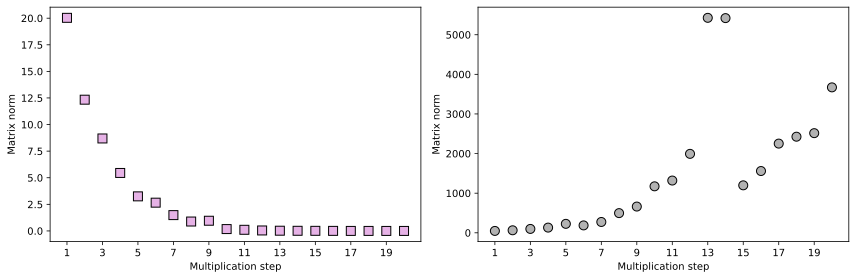

In [3]:
# scaling factor
scale_fact = 1.5

# number of multiplicaitons
num_mults = 20

# initialize random matrices
Asmol = torch.randn(30,30)
Abig  = torch.randn(30,30)

# initialize results
norms = torch.zeros(num_mults, 2)

# loop over N multiplications
for i in range(num_mults):
  Asmol *= torch.randn(30,30) * (1/scale_fact)
  norms[i, 0] = torch.norm(Asmol)

  Abig *= torch.randn(30,30) * scale_fact
  norms[i, 1] = torch.norm(Abig)

# draw the plots
_, axs = plt.subplots(1,2,figsize = (12,4))
axs[0].plot(range(1, num_mults + 1), norms[:,0], 'ks', markersize = 9, markerfacecolor = [.9,.7,.9])
axs[1].plot(range(1, num_mults + 1), norms[:,1], 'ko', markersize = 9, markerfacecolor = [.7,.7,.7])

for a, t in zip(axs, ['smaller', 'larger']):
  a.set(xticks = range(1, num_mults+1, 2), xlabel = 'Multiplication step', ylabel = 'Matrix norm')

plt.tight_layout()
plt.show()

# Create a matrix (activations matrix)

In [4]:
n_in  = 3
n_out = 10

A = torch.randn(n_in, n_out) * 2 + 3
torch.round(A)

tensor([[ 3.,  3.,  4.,  1.,  3.,  4.,  6.,  4.,  5.,  2.],
        [ 5.,  1.,  3.,  5.,  2.,  3.,  5.,  4.,  0.,  2.],
        [ 3.,  2.,  5.,  5.,  3.,  5., -1., -0.,  5.,  2.]])

Create a LayerNorm object instance

In [32]:
layer_norm = nn.LayerNorm((n_in, n_out)) # repeat with (n_in, n_out)
layer_norm

LayerNorm((3, 10), eps=1e-05, elementwise_affine=True)

Apply layer_norm to the weights matrix

In [33]:
normA = layer_norm(A)
print('Original matrix:\n', torch.round(A))
print('\nLayer-normed matrix:\n', torch.round(normA))

Original matrix:
 tensor([[ 3.,  3.,  4.,  1.,  3.,  4.,  6.,  4.,  5.,  2.],
        [ 5.,  1.,  3.,  5.,  2.,  3.,  5.,  4.,  0.,  2.],
        [ 3.,  2.,  5.,  5.,  3.,  5., -1., -0.,  5.,  2.]])

Layer-normed matrix:
 tensor([[-0.,  0.,  0., -1., -0.,  0.,  2.,  0.,  1., -1.],
        [ 1., -1., -0.,  1., -1., -0.,  1.,  1., -2., -1.],
        [-0., -1.,  1.,  1., -0.,  1., -2., -2.,  1., -1.]],
       grad_fn=<RoundBackward0>)


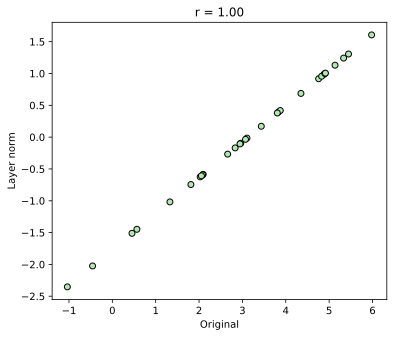

In [34]:
# how does layernorm change the matrix?

# convenence variables
a1 = A.detach().flatten()
a2 = normA.detach().flatten()

# correlation between them
r  = torch.sum((a1-a1.mean()) * (a2-a2.mean()))
r /= torch.sqrt(torch.sum((a1-a1.mean())**2) * torch.sum((a2-a2.mean())**2))

# scatter plot
plt.figure(figsize = (6,5))
plt.plot(a1, a2, 'ko', markerfacecolor = [.7,.9,.7])

plt.gca().set(xlabel = 'Original', ylabel = 'Layer norm', title = f'r = {r:.2f}')

plt.show()

In [35]:
print('ORIGINAL: mean across columns for each row:')
print(f'   {torch.mean(A, axis = 1)}\n')
print('LAYERNORM: mean across columns for each row:')
print(f'   {torch.mean(normA, axis = 1).detach()}\n')
print('----------------------------------------------\n')
print('ORIGINAL: std across columns for each row:')
print(f'   {torch.std(A, axis = 1)}\n')
print('LAYERNORM: std across columns for each row:')
print(f'   {torch.std(normA, axis = 1).detach()}\n')
print('----------------------------------------------\n\n\n')
print('LAYERNORM: mean across rows for each column:')
print(f'   {torch.mean(normA, axis = 0).detach()}\n')
print('LAYERNORM: std across rows for each column:')
print(f'   {torch.std(normA, axis = 0).detach()}')

ORIGINAL: mean across columns for each row:
   tensor([3.4126, 3.1443, 2.8399])

LAYERNORM: mean across columns for each row:
   tensor([ 0.1582,  0.0068, -0.1650])

----------------------------------------------

ORIGINAL: std across columns for each row:
   tensor([1.4871, 1.7274, 2.2567])

LAYERNORM: std across columns for each row:
   tensor([0.8391, 0.9747, 1.2733])

----------------------------------------------



LAYERNORM: mean across rows for each column:
   tensor([ 0.2885, -0.4801,  0.5339,  0.2716, -0.2486,  0.3835,  0.0794, -0.3194,
         0.1372, -0.6460])

LAYERNORM: std across rows for each column:
   tensor([0.7300, 0.6024, 0.6497, 1.4995, 0.3285, 0.6339, 2.1291, 1.4846, 1.4285,
        0.0864])


Inspect the layernorm parameters

In [36]:
print(f'Value of "gamma" (stretch/scale param): {layer_norm.weight}\n')
print(f'Value of "beta": (shift param):         {layer_norm.bias}')

Value of "gamma" (stretch/scale param): Parameter containing:
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], requires_grad=True)

Value of "beta": (shift param):         Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], requires_grad=True)


Modify the layernorm aprams and reapply to data

In [39]:
# layer_norm.weight = torch.nn.Parameter(torch.ones(n_out)*3)
# layer_norm.bias   = torch.nn.Parameter(torch.ones(n_out)*5)

layer_norm.weight = torch.nn.Parameter(torch.ones(n_in, n_out) * 3)
layer_norm.bias   = torch.nn.Parameter(torch.ones(n_in, n_out) * 5)

layer_norm.weight, layer_norm.bias

(Parameter containing:
 tensor([[3., 3., 3., 3., 3., 3., 3., 3., 3., 3.],
         [3., 3., 3., 3., 3., 3., 3., 3., 3., 3.],
         [3., 3., 3., 3., 3., 3., 3., 3., 3., 3.]], requires_grad=True),
 Parameter containing:
 tensor([[5., 5., 5., 5., 5., 5., 5., 5., 5., 5.],
         [5., 5., 5., 5., 5., 5., 5., 5., 5., 5.],
         [5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]], requires_grad=True))

In [40]:
norm_A_new = layer_norm(A)

print('ORIGINAL: mean across columns for each row:')
print(f'   {torch.mean(A, axis=1)}\n')
print('ORIGINAL: std across columns for each row:')
print(f'   {torch.std(A, axis = 1)}\n')

print('NEW LAYERNORM: mean across columns for each row:')
print(f'   {torch.mean(norm_A_new, axis = 1).detach()}\n')
print('NEW LAYERNORM: std across columns for each row:')
print(f'   {torch.std(norm_A_new, axis = 1).detach()}\n')

ORIGINAL: mean across columns for each row:
   tensor([3.4126, 3.1443, 2.8399])

ORIGINAL: std across columns for each row:
   tensor([1.4871, 1.7274, 2.2567])

NEW LAYERNORM: mean across columns for each row:
   tensor([5.4746, 5.0203, 4.5051])

NEW LAYERNORM: std across columns for each row:
   tensor([2.5172, 2.9240, 3.8198])

